In [88]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

In [89]:
df = pd.read_csv("placement.csv")
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [90]:
df.describe()

,cgpa,placement_exam_marks,placed
count,1000.000000,1000.000000,1000.000000
mean,6.961240,32.225000,0.489000
std,0.615898,19.130822,0.500129
min,4.890000,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,9.120000,100.000000,1.000000


<Axes: >

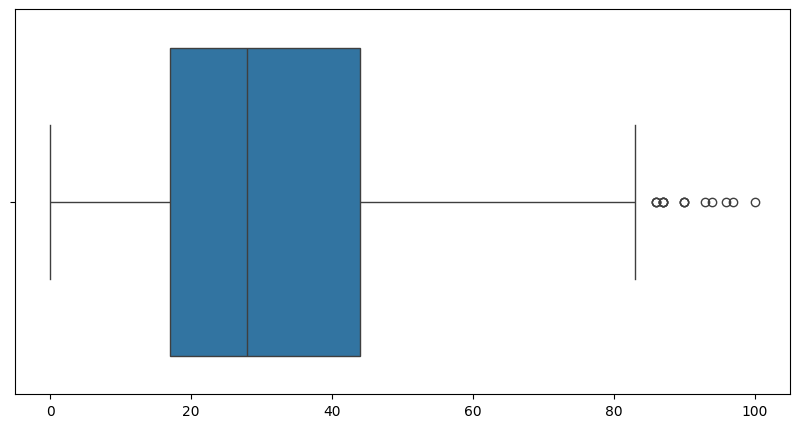

In [91]:
x = df["placement_exam_marks"].values
plt.figure(figsize=(10,5))
sns.boxplot(x=x)

<Axes: xlabel='placement_exam_marks', ylabel='cgpa'>

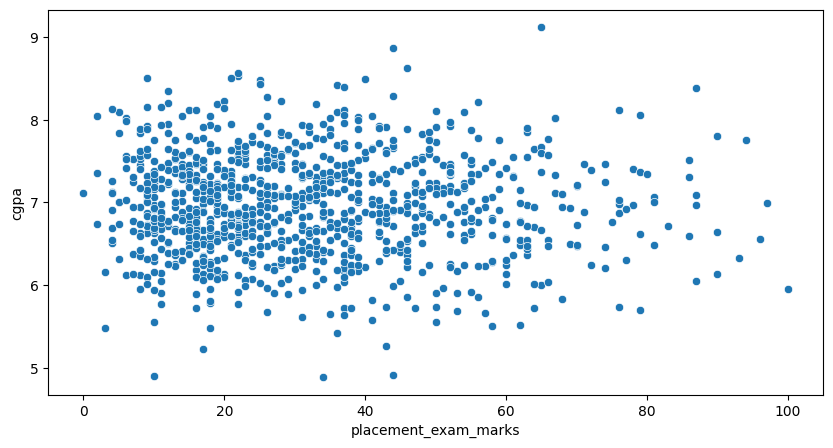

In [92]:
plt.figure(figsize=(10,5))
sns.scatterplot(x=df["placement_exam_marks"],y=df["cgpa"])

<Figure size 1000x500 with 0 Axes>

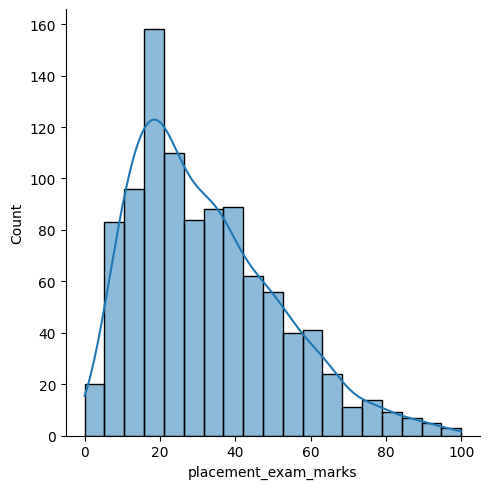

In [93]:
plt.figure(figsize=(10,5))
sns.displot(df["placement_exam_marks"],kde=True)

TRIMMING - PERCENTLIE METHOD

In [94]:
#min - 0.00 and max- 100.00 according to the dataset. So we can say that there are some outliers in the dataset. We can handle them by using percentile method.
#so we take lower and upper limit - 0.01 and 0.99 
upper_limit = df["placement_exam_marks"].quantile(0.99)
lower_limit = df["placement_exam_marks"].quantile(0.01)

In [95]:
new_df = df[
    (df["placement_exam_marks"] >= lower_limit) & 
    (df["placement_exam_marks"] <= upper_limit)
]

In [96]:
new_df.describe()


,cgpa,placement_exam_marks,placed
count,986.000000,986.000000,986.000000
mean,6.963682,31.909736,0.488844
std,0.613742,18.294183,0.500129
min,4.890000,4.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,9.120000,87.000000,1.000000


<Figure size 1000x500 with 0 Axes>

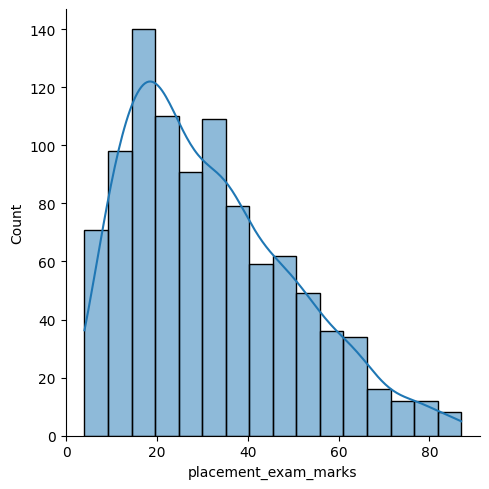

In [97]:
plt.figure(figsize=(10,5))
sns.displot(new_df["placement_exam_marks"],kde=True)

C:\Users\vinay kumar\AppData\Local\Temp\ipykernel_3708\1733128361.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['placement_exam_marks'])
C:\Users\vinay kumar\AppData\Local\Temp\ipykernel_3708\1733128361.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


<Axes: xlabel='placement_exam_marks', ylabel='Density'>

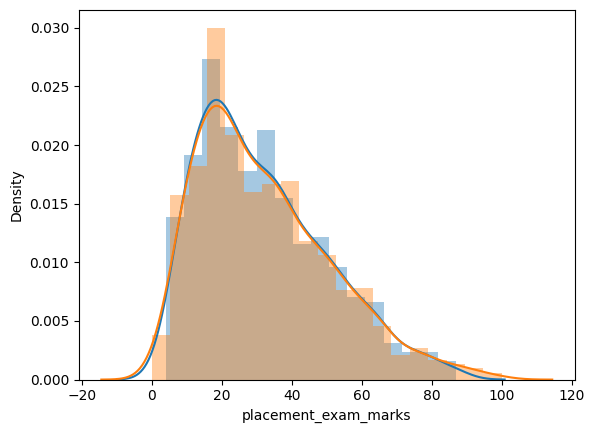

In [98]:
sns.distplot(new_df['placement_exam_marks'])

sns.distplot(df['placement_exam_marks'])


<Axes: >

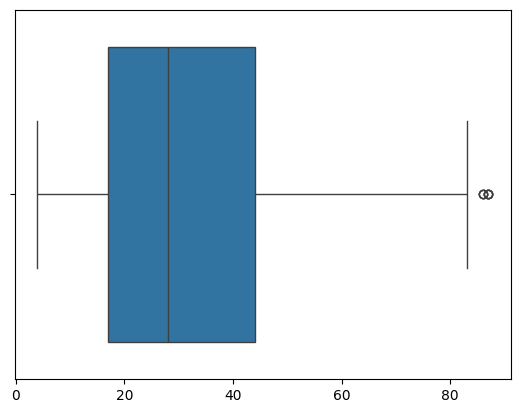

In [99]:
sns.boxplot(x=new_df["placement_exam_marks"].values)


CAPPING - PERCENTILE METHOD

In [107]:
data=np.where(df["placement_exam_marks"] > upper_limit,
         upper_limit,
         np.where(df["placement_exam_marks"] < lower_limit,
                  lower_limit,
                  df["placement_exam_marks"]))

In [114]:
data = pd.DataFrame(data,columns=["placement_exam_marks"])

<Axes: xlabel='placement_exam_marks'>

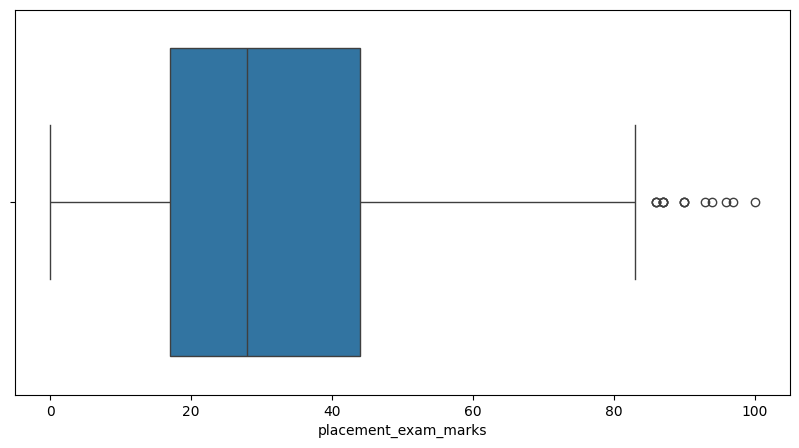

In [106]:
plt.figure(figsize=(10,5))
sns.boxplot(x= df["placement_exam_marks"])

<Axes: >

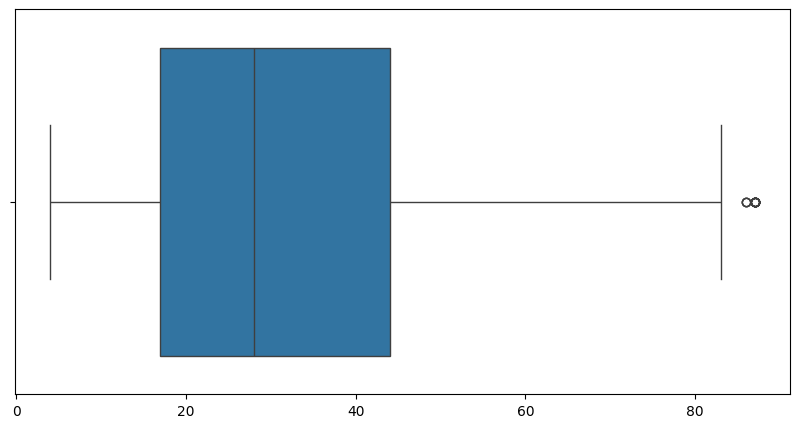

In [116]:

plt.figure(figsize=(10,5))
sns.boxplot(x=data["placement_exam_marks"].values)